In [1]:
# 00 - Imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import optuna
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

#import mlflow
#import mlflow.sklearn
#mlflow.set_tracking_uri("http://127.0.0.1:5000")
#mlflow.set_experiment("home_credit_scoring")

C:\Users\mouto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 01 - Paramètres

DATA_DIR = "src"

RANDOM_STATE = 42
TEST_SIZE = 0.2

FN_COST = 10
FP_COST = 1

In [3]:
# 02 - Chargement des fichiers

application_train = pd.read_csv(os.path.join(DATA_DIR, "application_train.csv"))
bureau = pd.read_csv(os.path.join(DATA_DIR, "bureau.csv"))
bureau_balance = pd.read_csv(os.path.join(DATA_DIR, "bureau_balance.csv"))
previous_application = pd.read_csv(os.path.join(DATA_DIR, "previous_application.csv"))
installments_payments = pd.read_csv(os.path.join(DATA_DIR, "installments_payments.csv"))
pos_cash_balance = pd.read_csv(os.path.join(DATA_DIR, "POS_CASH_balance.csv"))
credit_card_balance = pd.read_csv(os.path.join(DATA_DIR, "credit_card_balance.csv"))

print(application_train.shape)
application_train.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


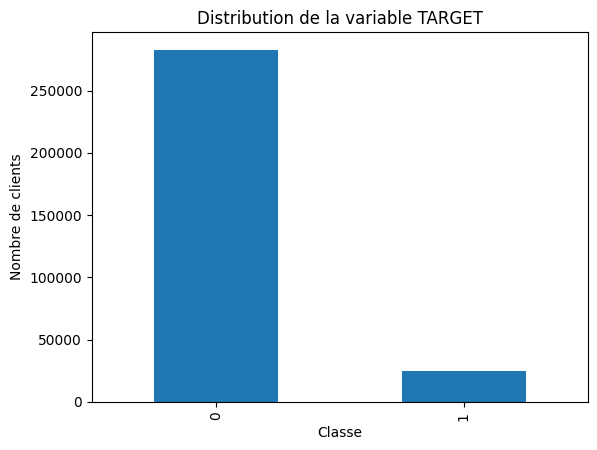

In [4]:
# 03 - Distribution de la cible

target_counts = application_train["TARGET"].value_counts(normalize=True) * 100

print(target_counts)

application_train["TARGET"].value_counts().plot(kind="bar")
plt.title("Distribution de la variable TARGET")
plt.xlabel("Classe")
plt.ylabel("Nombre de clients")
plt.show()

In [5]:
# 04 - Fonction utilitaire pour renommer les colonnes agrégées

def flatten_columns(df, prefix):
    df.columns = [
        prefix + "_" + "_".join(col).strip()
        if isinstance(col, tuple)
        else prefix + "_" + col
        for col in df.columns
    ]
    return df

In [6]:
# 05 - Agrégation bureau

bureau_num = bureau.select_dtypes(include=["int64", "float64"]).copy()
bureau_num["SK_ID_CURR"] = bureau["SK_ID_CURR"]

bureau_agg = bureau_num.groupby("SK_ID_CURR").agg(["mean", "min", "max", "sum", "count"])
bureau_agg = flatten_columns(bureau_agg, "bureau")
bureau_agg.reset_index(inplace=True)

bureau_agg.head()

,SK_ID_CURR,bureau_SK_ID_BUREAU_mean,bureau_SK_ID_BUREAU_min,bureau_SK_ID_BUREAU_max,bureau_SK_ID_BUREAU_sum,bureau_SK_ID_BUREAU_count,bureau_DAYS_CREDIT_mean,bureau_DAYS_CREDIT_min,bureau_DAYS_CREDIT_max,bureau_DAYS_CREDIT_sum,...,bureau_DAYS_CREDIT_UPDATE_mean,bureau_DAYS_CREDIT_UPDATE_min,bureau_DAYS_CREDIT_UPDATE_max,bureau_DAYS_CREDIT_UPDATE_sum,bureau_DAYS_CREDIT_UPDATE_count,bureau_AMT_ANNUITY_mean,bureau_AMT_ANNUITY_min,bureau_AMT_ANNUITY_max,bureau_AMT_ANNUITY_sum,bureau_AMT_ANNUITY_count
0,100001,5896633.000,5896630,5896636,41276431,7,-735.000000,-1572,-49,-5145,...,-93.142857,-155,-6,-652,7,3545.357143,0.0,10822.5,24817.5,7
1,100002,6153272.125,6113835,6158909,49226177,8,-874.000000,-1437,-103,-6992,...,-499.875000,-1185,-7,-3999,8,0.000000,0.0,0.0,0.0,7
2,100003,5885878.500,5885877,5885880,23543514,4,-1400.750000,-2586,-606,-5603,...,-816.000000,-2131,-43,-3264,4,NaN,NaN,NaN,0.0,0
3,100004,6829133.500,6829133,6829134,13658267,2,-867.000000,-1326,-408,-1734,...,-532.000000,-682,-382,-1064,2,NaN,NaN,NaN,0.0,0
4,100005,6735201.000,6735200,6735202,20205603,3,-190.666667,-373,-62,-572,...,-54.333333,-121,-11,-163,3,1420.500000,0.0,4261.5,4261.5,3


In [7]:
# 06 - Agrégation previous_application

previous_num = previous_application.select_dtypes(include=["int64", "float64"]).copy()
previous_num["SK_ID_CURR"] = previous_application["SK_ID_CURR"]

previous_agg = previous_num.groupby("SK_ID_CURR").agg(["mean", "min", "max", "sum", "count"])
previous_agg = flatten_columns(previous_agg, "previous")
previous_agg.reset_index(inplace=True)

previous_agg.head()

,SK_ID_CURR,previous_SK_ID_PREV_mean,previous_SK_ID_PREV_min,previous_SK_ID_PREV_max,previous_SK_ID_PREV_sum,previous_SK_ID_PREV_count,previous_AMT_ANNUITY_mean,previous_AMT_ANNUITY_min,previous_AMT_ANNUITY_max,previous_AMT_ANNUITY_sum,...,previous_DAYS_TERMINATION_mean,previous_DAYS_TERMINATION_min,previous_DAYS_TERMINATION_max,previous_DAYS_TERMINATION_sum,previous_DAYS_TERMINATION_count,previous_NFLAG_INSURED_ON_APPROVAL_mean,previous_NFLAG_INSURED_ON_APPROVAL_min,previous_NFLAG_INSURED_ON_APPROVAL_max,previous_NFLAG_INSURED_ON_APPROVAL_sum,previous_NFLAG_INSURED_ON_APPROVAL_count
0,100001,1.369693e+06,1369693,1369693,1369693,1,3951.000,3951.000,3951.000,3951.000,...,-1612.000000,-1612.0,-1612.0,-1612.0,1,0.000000,0.0,0.0,0.0,1
1,100002,1.038818e+06,1038818,1038818,1038818,1,9251.775,9251.775,9251.775,9251.775,...,-17.000000,-17.0,-17.0,-17.0,1,0.000000,0.0,0.0,0.0,1
2,100003,2.281150e+06,1810518,2636178,6843451,3,56553.990,6737.310,98356.995,169661.970,...,-1047.333333,-1976.0,-527.0,-3142.0,3,0.666667,0.0,1.0,2.0,3
3,100004,1.564014e+06,1564014,1564014,1564014,1,5357.250,5357.250,5357.250,5357.250,...,-714.000000,-714.0,-714.0,-714.0,1,0.000000,0.0,0.0,0.0,1
4,100005,2.176837e+06,1857999,2495675,4353674,2,4813.200,4813.200,4813.200,4813.200,...,-460.000000,-460.0,-460.0,-460.0,1,0.000000,0.0,0.0,0.0,1


In [8]:
# 07 - Feature engineering installments

installments_payments["PAYMENT_DIFF"] = (
    installments_payments["AMT_PAYMENT"] - installments_payments["AMT_INSTALMENT"]
)

installments_payments["PAYMENT_RATIO"] = (
    installments_payments["AMT_PAYMENT"] / installments_payments["AMT_INSTALMENT"]
)

installments_payments["DAYS_PAYMENT_DIFF"] = (
    installments_payments["DAYS_ENTRY_PAYMENT"] - installments_payments["DAYS_INSTALMENT"]
)

installments_num = installments_payments.select_dtypes(include=["int64", "float64"]).copy()
installments_num["SK_ID_CURR"] = installments_payments["SK_ID_CURR"]

installments_agg = installments_num.groupby("SK_ID_CURR").agg(["mean", "min", "max", "sum", "count"])
installments_agg = flatten_columns(installments_agg, "installments")
installments_agg.reset_index(inplace=True)

installments_agg.head()

KeyboardInterrupt: 

In [ ]:
# 08 - Agrégation POS_CASH_balance

pos_num = pos_cash_balance.select_dtypes(include=["int64", "float64"]).copy()
pos_num["SK_ID_CURR"] = pos_cash_balance["SK_ID_CURR"]

pos_agg = pos_num.groupby("SK_ID_CURR").agg(["mean", "min", "max", "sum", "count"])
pos_agg = flatten_columns(pos_agg, "pos")
pos_agg.reset_index(inplace=True)

pos_agg.head()

,SK_ID_CURR,pos_SK_ID_PREV_mean,pos_SK_ID_PREV_min,pos_SK_ID_PREV_max,pos_SK_ID_PREV_sum,pos_SK_ID_PREV_count,pos_MONTHS_BALANCE_mean,pos_MONTHS_BALANCE_min,pos_MONTHS_BALANCE_max,pos_MONTHS_BALANCE_sum,...,pos_SK_DPD_mean,pos_SK_DPD_min,pos_SK_DPD_max,pos_SK_DPD_sum,pos_SK_DPD_count,pos_SK_DPD_DEF_mean,pos_SK_DPD_DEF_min,pos_SK_DPD_DEF_max,pos_SK_DPD_DEF_sum,pos_SK_DPD_DEF_count
0,100001,1.584045e+06,1369693,1851984,14256401,9,-72.555556,-96,-53,-653,...,0.777778,0,7,7,9,0.777778,0,7,7,9
1,100002,1.038818e+06,1038818,1038818,19737542,19,-10.000000,-19,-1,-190,...,0.000000,0,0,0,19,0.000000,0,0,0,19
2,100003,2.297665e+06,1810518,2636178,64334628,28,-43.785714,-77,-18,-1226,...,0.000000,0,0,0,28,0.000000,0,0,0,28
3,100004,1.564014e+06,1564014,1564014,6256056,4,-25.500000,-27,-24,-102,...,0.000000,0,0,0,4,0.000000,0,0,0,4
4,100005,2.495675e+06,2495675,2495675,27452425,11,-20.000000,-25,-15,-220,...,0.000000,0,0,0,11,0.000000,0,0,0,11


In [ ]:
# 09 - Agrégation credit_card_balance

credit_num = credit_card_balance.select_dtypes(include=["int64", "float64"]).copy()
credit_num["SK_ID_CURR"] = credit_card_balance["SK_ID_CURR"]

credit_agg = credit_num.groupby("SK_ID_CURR").agg(["mean", "min", "max", "sum", "count"])
credit_agg = flatten_columns(credit_agg, "credit")
credit_agg.reset_index(inplace=True)

credit_agg.head()

,SK_ID_CURR,credit_SK_ID_PREV_mean,credit_SK_ID_PREV_min,credit_SK_ID_PREV_max,credit_SK_ID_PREV_sum,credit_SK_ID_PREV_count,credit_MONTHS_BALANCE_mean,credit_MONTHS_BALANCE_min,credit_MONTHS_BALANCE_max,credit_MONTHS_BALANCE_sum,...,credit_SK_DPD_mean,credit_SK_DPD_min,credit_SK_DPD_max,credit_SK_DPD_sum,credit_SK_DPD_count,credit_SK_DPD_DEF_mean,credit_SK_DPD_DEF_min,credit_SK_DPD_DEF_max,credit_SK_DPD_DEF_sum,credit_SK_DPD_DEF_count
0,100006,1489396.0,1489396,1489396,8936376,6,-3.5,-6,-1,-21,...,0.000000,0,0,0,6,0.000000,0,0,0,6
1,100011,1843384.0,1843384,1843384,136410416,74,-38.5,-75,-2,-2849,...,0.000000,0,0,0,74,0.000000,0,0,0,74
2,100013,2038692.0,2038692,2038692,195714432,96,-48.5,-96,-1,-4656,...,0.010417,0,1,1,96,0.010417,0,1,1,96
3,100021,2594025.0,2594025,2594025,44098425,17,-10.0,-18,-2,-170,...,0.000000,0,0,0,17,0.000000,0,0,0,17
4,100023,1499902.0,1499902,1499902,11999216,8,-7.5,-11,-4,-60,...,0.000000,0,0,0,8,0.000000,0,0,0,8


In [ ]:
# 10 - Fusion des tables agrégées

df = application_train.copy()

for agg_df in [bureau_agg, previous_agg, installments_agg, pos_agg, credit_agg]:
    df = df.merge(agg_df, on="SK_ID_CURR", how="left")

print(df.shape)
df.head()

(307511, 472)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,credit_SK_DPD_mean,credit_SK_DPD_min,credit_SK_DPD_max,credit_SK_DPD_sum,credit_SK_DPD_count,credit_SK_DPD_DEF_mean,credit_SK_DPD_DEF_min,credit_SK_DPD_DEF_max,credit_SK_DPD_DEF_sum,credit_SK_DPD_DEF_count
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,6.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# 11 - Nettoyage simple

df = df.replace([np.inf, -np.inf], np.nan)

# Suppression des colonnes avec trop de valeurs manquantes
missing_rate = df.isna().mean()
cols_to_drop = missing_rate[missing_rate > 0.8].index.tolist()

print(f"Colonnes supprimées : {len(cols_to_drop)}")

df = df.drop(columns=cols_to_drop)

print(df.shape)

Colonnes supprimées : 27
(307511, 445)


In [ ]:
# 12 - Séparation features / target

y = df["TARGET"]
X = df.drop(columns=["TARGET", "SK_ID_CURR"])

print(X.shape)
print(y.shape)

(307511, 443)
(307511,)


In [ ]:
# 13 - Train / Test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(246008, 443)
(61503, 443)


In [ ]:
# 14 - Préprocessing

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
# 15 - Fonction de coût métier

def business_cost(y_true, y_pred, fn_cost=10, fp_cost=1):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn_cost * fn + fp_cost * fp


def find_best_threshold(y_true, y_proba, fn_cost=10, fp_cost=1):
    thresholds = np.arange(0.01, 1.00, 0.01)

    results = []

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        cost = business_cost(y_true, y_pred, fn_cost, fp_cost)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        results.append({
            "threshold": threshold,
            "business_cost": cost,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp
        })

    results_df = pd.DataFrame(results)
    best_row = results_df.loc[results_df["business_cost"].idxmin()]

    return best_row, results_df

In [ ]:
# 16 - Configuration MLflow

mlflow.set_experiment("home_credit_scoring")

<Experiment: artifact_location='file:c:/Users/mouto/Documents/Jedha/OCR_Projects/OCR_Projet_6/mlruns/1', creation_time=1777628500979, experiment_id='1', last_update_time=1777628500979, lifecycle_stage='active', name='home_credit_scoring', tags={}, trace_location=None, workspace='default'>

In [ ]:
# 17 - Fonction d'entraînement avec MLflow

def train_and_log_model(model_name, model, X_train, X_test, y_train, y_test):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    with mlflow.start_run(run_name=model_name):
        pipeline.fit(X_train, y_train)

        y_proba = pipeline.predict_proba(X_test)[:, 1]

        best_threshold_row, threshold_results = find_best_threshold(
            y_test,
            y_proba,
            fn_cost=FN_COST,
            fp_cost=FP_COST
        )

        best_threshold = best_threshold_row["threshold"]
        y_pred = (y_proba >= best_threshold).astype(int)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)
        cost = business_cost(y_test, y_pred, FN_COST, FP_COST)

        mlflow.log_param("model_name", model_name)
        mlflow.log_param("best_threshold", best_threshold)
        mlflow.log_param("fn_cost", FN_COST)
        mlflow.log_param("fp_cost", FP_COST)

        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("roc_auc", auc)
        mlflow.log_metric("business_cost", cost)

        mlflow.log_metric("false_negatives", int(best_threshold_row["fn"]))
        mlflow.log_metric("false_positives", int(best_threshold_row["fp"]))

        os.makedirs("artifacts", exist_ok=True)

        artifact_path = "artifacts/threshold_results.csv"
        threshold_results.to_csv(artifact_path, index=False)

        mlflow.log_artifact(artifact_path)

        mlflow.sklearn.log_model(pipeline, artifact_path="model")

        print(model_name)
        print("Best threshold:", best_threshold)
        print("Business cost:", cost)
        print("ROC-AUC:", auc)
        print(classification_report(y_test, y_pred))

        return pipeline, threshold_results

In [ ]:
# 18 - Modèle baseline : Logistic Regression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

log_reg_pipeline, log_reg_thresholds = train_and_log_model(
    "LogisticRegression_baseline",
    log_reg,
    X_train,
    X_test,
    y_train,
    y_test
)

2026/05/22 10:04:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/22 10:04:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LogisticRegression_baseline
Best threshold: 0.52
Business cost: 31139
ROC-AUC: 0.773391172855715
              precision    recall  f1-score   support

           0       0.96      0.73      0.83     56538
           1       0.18      0.67      0.29      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.70      0.56     61503
weighted avg       0.90      0.73      0.79     61503

🏃 View run LogisticRegression_baseline at: http://127.0.0.1:5000/#/experiments/1/runs/d0034743cbf746f0a78ae0023f885683
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [ ]:
# 19 - Random Forest

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_pipeline, rf_thresholds = train_and_log_model(
    "RandomForest_baseline",
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

2026/05/22 10:06:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/22 10:06:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest_baseline
Best threshold: 0.49
Business cost: 33536
ROC-AUC: 0.7450816046970985
              precision    recall  f1-score   support

           0       0.96      0.71      0.82     56538
           1       0.17      0.66      0.26      4965

    accuracy                           0.70     61503
   macro avg       0.56      0.68      0.54     61503
weighted avg       0.90      0.70      0.77     61503

🏃 View run RandomForest_baseline at: http://127.0.0.1:5000/#/experiments/1/runs/35f2deaac4f14205b205b6c29845a2c9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


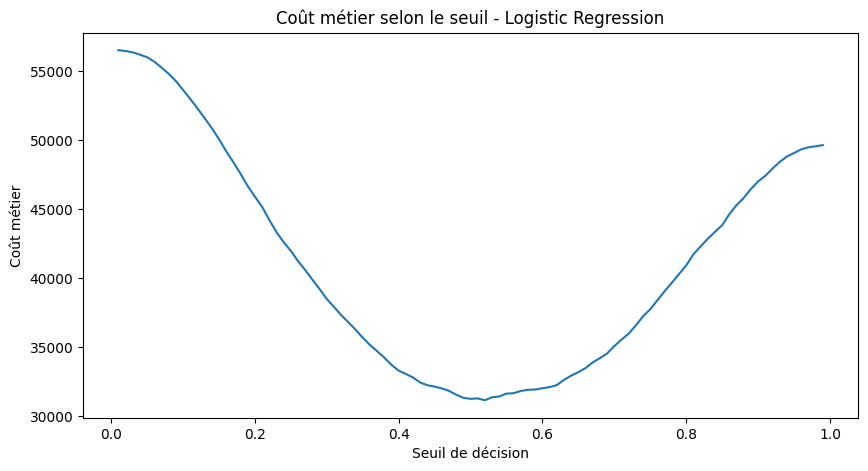

In [ ]:
# 20 - Visualisation du coût métier selon le seuil

plt.figure(figsize=(10, 5))
plt.plot(log_reg_thresholds["threshold"], log_reg_thresholds["business_cost"])
plt.xlabel("Seuil de décision")
plt.ylabel("Coût métier")
plt.title("Coût métier selon le seuil - Logistic Regression")
plt.show()

In [ ]:
# 21 - Optimisation bayésienne Optuna allégée

import optuna
from sklearn.model_selection import cross_val_score

# Sous-échantillon stratifié pour accélérer l'optimisation
X_opt, _, y_opt, _ = train_test_split(
    X_train,
    y_train,
    train_size=50000,
    stratify=y_train,
    random_state=RANDOM_STATE
)

def objective(trial):
    C = trial.suggest_float("C", 0.001, 10.0, log=True)

    pipeline_optuna = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            C=C,
            solver="liblinear",
            max_iter=500,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ])

    cv = StratifiedKFold(
        n_splits=2,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    scores = cross_val_score(
        pipeline_optuna,
        X_opt,
        y_opt,
        scoring="roc_auc",
        cv=cv,
        n_jobs=1
    )

    return scores.mean()


study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=8,
    show_progress_bar=True
)

print("Meilleurs hyperparamètres :", study.best_params)
print("Meilleur ROC-AUC CV :", study.best_value)

[I 2026-05-22 10:06:19,832] A new study created in memory with name: no-name-2bb1690a-66b8-4a84-b550-07142ebd764a
Best trial: 0. Best value: 0.746558:  12%|█▎        | 1/8 [02:52<20:08, 172.58s/it]

[I 2026-05-22 10:09:12,417] Trial 0 finished with value: 0.746558322586065 and parameters: {'C': 6.093493779470798}. Best is trial 0 with value: 0.746558322586065.


Best trial: 1. Best value: 0.746849:  25%|██▌       | 2/8 [05:29<16:18, 163.15s/it]

[I 2026-05-22 10:11:48,962] Trial 1 finished with value: 0.7468489149822859 and parameters: {'C': 3.036546096333109}. Best is trial 1 with value: 0.7468489149822859.


Best trial: 2. Best value: 0.74829:  38%|███▊      | 3/8 [06:18<09:16, 111.27s/it] 

...

[I 2026-05-22 10:13:24,934] Trial 5 finished with value: 0.7560660542800808 and parameters: {'C': 0.0010218296028312993}. Best is trial 5 with value: 0.7560660542800808.


Best trial: 5. Best value: 0.756066:  88%|████████▊ | 7/8 [07:15<00:29, 29.84s/it]

[I 2026-05-22 10:13:35,584] Trial 6 finished with value: 0.7557038110318421 and parameters: {'C': 0.0024650440217529024}. Best is trial 5 with value: 0.7560660542800808.


Best trial: 5. Best value: 0.756066: 100%|██████████| 8/8 [08:14<00:00, 61.82s/it]

[I 2026-05-22 10:14:34,407] Trial 7 finished with value: 0.7478993233727365 and parameters: {'C': 0.6357261787691196}. Best is trial 5 with value: 0.7560660542800808.
Meilleurs hyperparamètres : {'C': 0.0010218296028312993}
Meilleur ROC-AUC CV : 0.7560660542800808


In [ ]:
# 22 - Entraînement et logging du meilleur modèle Optuna

best_params = study.best_params

best_model_optuna = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        C=best_params["C"],
        solver="liblinear",
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

with mlflow.start_run(run_name="LogisticRegression_Optuna"):
    best_model_optuna.fit(X_train, y_train)

    y_proba = best_model_optuna.predict_proba(X_test)[:, 1]

    best_threshold_row, threshold_results = find_best_threshold(
        y_test,
        y_proba,
        fn_cost=FN_COST,
        fp_cost=FP_COST
    )

    best_threshold = best_threshold_row["threshold"]
    y_pred = (y_proba >= best_threshold).astype(int)

    mlflow.log_params(best_params)
    mlflow.log_param("solver", "liblinear")
    mlflow.log_param("optimization_method", "optuna_bayesian")
    mlflow.log_param("best_threshold", best_threshold)

    mlflow.log_metric("cv_best_roc_auc", study.best_value)
    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred))
    mlflow.log_metric("precision", precision_score(y_test, y_pred, zero_division=0))
    mlflow.log_metric("recall", recall_score(y_test, y_pred))
    mlflow.log_metric("f1_score", f1_score(y_test, y_pred))
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_proba))
    mlflow.log_metric("business_cost", business_cost(y_test, y_pred, FN_COST, FP_COST))
    mlflow.log_metric("false_negatives", int(best_threshold_row["fn"]))
    mlflow.log_metric("false_positives", int(best_threshold_row["fp"]))

    os.makedirs("artifacts", exist_ok=True)

    threshold_path = "artifacts/threshold_results_optuna.csv"
    threshold_results.to_csv(threshold_path, index=False)

    mlflow.log_artifact(threshold_path)

    mlflow.sklearn.log_model(
        best_model_optuna,
        artifact_path="model",
        registered_model_name="home_credit_scoring_model"
    )

print("Modèle Optuna enregistré dans MLflow Registry.")

2026/05/22 10:15:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/22 10:15:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'home_credit_scoring_model' already exists. Creating a new version of this model...
2026/05/22 10:15:50 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: home_credit_scoring_model, version 5
Created version '5' of model 'home_credit_scoring_model'.


🏃 View run LogisticRegression_Optuna at: http://127.0.0.1:5000/#/experiments/1/runs/6a6ef8f6a0cf4766a03434ae626afbe4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Modèle Optuna enregistré dans MLflow Registry.


In [ ]:
import requests
import json
import numpy as np
import pandas as pd

sample = X_test.iloc[:1].copy()
sample = sample.astype(object).where(pd.notnull(sample), None)

payload = {
    "dataframe_split": sample.to_dict(orient="split")
}

response = requests.post(
    "http://127.0.0.1:5001/invocations",
    data=json.dumps(payload),
    headers={"Content-Type": "application/json"}
)

print(response.status_code)
print(response.text)

200
{"predictions": [0]}


In [ ]:
import shap
import scipy.sparse

In [ ]:
# Sous-échantillon pour explicabilité

X_shap = X_test.sample(
    1000,
    random_state=RANDOM_STATE
)

In [ ]:
# Transformation

X_shap_transformed = best_model_optuna.named_steps["preprocessor"].transform(X_shap)

feature_names = best_model_optuna.named_steps["preprocessor"].get_feature_names_out()

print(X_shap_transformed.shape)
print(len(feature_names))

(1000, 567)
567


In [ ]:
# Traduction lisible des noms de variables pour SHAP

base_feature_mapping = {
    "EXT_SOURCE_1": "Score externe 1",
    "EXT_SOURCE_2": "Score externe 2",
    "EXT_SOURCE_3": "Score externe 3",

    "AMT_INCOME_TOTAL": "Revenus annuels",
    "AMT_CREDIT": "Montant du crédit",
    "AMT_ANNUITY": "Mensualité du crédit",
    "AMT_GOODS_PRICE": "Prix du bien financé",
    "AMT_CREDIT_SUM_DEBT": "Dette des crédits externes",
    "AMT_CREDIT_SUM": "Montant total des crédits externes",

    "DAYS_BIRTH": "Âge client",
    "DAYS_EMPLOYED": "Ancienneté emploi",
    "DAYS_CREDIT": "Ancienneté crédit externe",
    "DAYS_ENDDATE_FACT": "Date réelle fin crédit externe",

    "CNT_INSTALMENT": "Nombre d'échéances",
    "CNT_INSTALMENT_FUTURE": "Échéances restantes",
    "NUM_INSTALMENT_NUMBER": "Numéro d'échéance",
    "MONTHS_BALANCE": "Ancienneté mensuelle",
    "SK_ID_BUREAU": "Nombre crédits bureau",

    "PAYMENT_RATIO": "Ratio paiement / échéance",
    "PAYMENT_DIFF": "Écart montant payé / échéance",
}

prefix_mapping = {
    "bureau": "Historique crédits externes",
    "previous": "Demandes précédentes",
    "installments": "Paiements précédents",
    "pos": "Crédits POS / Cash",
    "credit": "Carte crédit",
}

agg_mapping = {
    "mean": "moyenne",
    "min": "minimum",
    "max": "maximum",
    "sum": "total",
    "count": "nombre",
}

category_mapping = {
    "CODE_GENDER": "Genre",
    "NAME_CONTRACT_TYPE": "Type de contrat",
    "FLAG_OWN_CAR": "Possède une voiture",
    "FLAG_OWN_REALTY": "Possède un bien immobilier",
    "NAME_INCOME_TYPE": "Type de revenu",
    "NAME_EDUCATION_TYPE": "Niveau d'éducation",
    "NAME_FAMILY_STATUS": "Situation familiale",
    "NAME_HOUSING_TYPE": "Type de logement",
    "OCCUPATION_TYPE": "Profession",
    "ORGANIZATION_TYPE": "Type d'organisation employeur",
}


def clean_value(value):
    return (
        str(value)
        .replace("_", " ")
        .replace("  ", " ")
        .strip()
    )


def translate_raw_feature(raw_name):
    # Variables agrégées : bureau_X_mean, pos_X_sum, etc.
    for prefix, prefix_label in prefix_mapping.items():
        prefix_pattern = prefix + "_"

        if raw_name.startswith(prefix_pattern):
            without_prefix = raw_name.replace(prefix_pattern, "", 1)

            for agg, agg_label in agg_mapping.items():
                suffix_pattern = "_" + agg

                if without_prefix.endswith(suffix_pattern):
                    variable = without_prefix[: -len(suffix_pattern)]
                    readable_var = base_feature_mapping.get(variable, clean_value(variable))
                    return f"{prefix_label} - {readable_var} ({agg_label})"

            readable_var = base_feature_mapping.get(without_prefix, clean_value(without_prefix))
            return f"{prefix_label} - {readable_var}"

    # Variables classiques
    return base_feature_mapping.get(raw_name, clean_value(raw_name))


def translate_feature_name(feature_name):
    name = str(feature_name)

    # Retirer préfixe sklearn numérique avant analyse agrégée
    if name.startswith("num__"):
        raw_name = name.replace("num__", "", 1)
        return translate_raw_feature(raw_name)

    # Variables catégorielles one-hot
    if name.startswith("cat__"):
        raw_name = name.replace("cat__", "", 1)

        for cat_col, cat_label in category_mapping.items():
            if raw_name.startswith(cat_col + "_"):
                value = raw_name.replace(cat_col + "_", "", 1)
                return f"{cat_label} : {clean_value(value)}"

        return clean_value(raw_name)

    return translate_raw_feature(name)


readable_feature_names = [
    translate_feature_name(name)
    for name in feature_names
]

pd.DataFrame({
    "feature_originale": feature_names,
    "feature_lisible": readable_feature_names
}).head(80)

,feature_originale,feature_lisible
0,num__CNT_CHILDREN,CNT CHILDREN
1,num__AMT_INCOME_TOTAL,Revenus annuels
2,num__AMT_CREDIT,Montant du crédit
3,num__AMT_ANNUITY,Mensualité du crédit
4,num__AMT_GOODS_PRICE,Prix du bien financé
...,...,...
75,num__OBS_60_CNT_SOCIAL_CIRCLE,OBS 60 CNT SOCIAL CIRCLE
76,num__DEF_60_CNT_SOCIAL_CIRCLE,DEF 60 CNT SOCIAL CIRCLE
77,num__DAYS_LAST_PHONE_CHANGE,DAYS LAST PHONE CHANGE
78,num__FLAG_DOCUMENT_2,FLAG DOCUMENT 2


In [ ]:
# Explainer

model = best_model_optuna.named_steps["model"]

explainer = shap.LinearExplainer(
    model,
    X_shap_transformed
)

shap_values = explainer(X_shap_transformed)

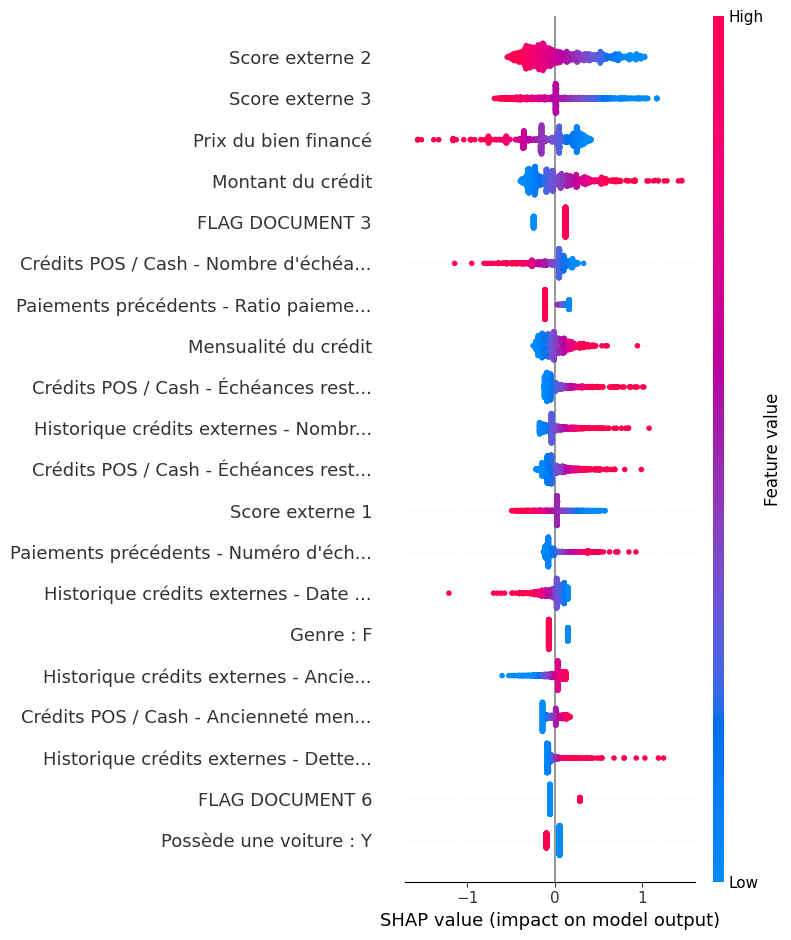

In [ ]:
max_len = 35

short_feature_names = [
    name[:max_len] + "..."
    if len(name) > max_len
    else name
    for name in readable_feature_names
]

plt.figure(figsize=(18, 10))

shap.summary_plot(
    shap_values,
    X_shap_transformed,
    feature_names=short_feature_names,
    show=False
)

plt.tight_layout()
plt.show()

In [ ]:
shap_importance = pd.DataFrame({
    "feature": readable_feature_names,
    "importance": np.abs(shap_values.values).mean(axis=0)
}).sort_values(
    by="importance",
    ascending=False
)

shap_importance.head(20)

,feature,importance
28,Score externe 2,0.298625
29,Score externe 3,0.276827
4,Prix du bien financé,0.253505
2,Montant du crédit,0.232015
79,FLAG DOCUMENT 3,0.156160
323,Crédits POS / Cash - Nombre d'échéances (moyenne),0.146043
304,Paiements précédents - Ratio paiement / échéan...,0.127878
3,Mensualité du crédit,0.116322
331,Crédits POS / Cash - Échéances restantes (total),0.114140
107,Historique crédits externes - Nombre crédits b...,0.113793


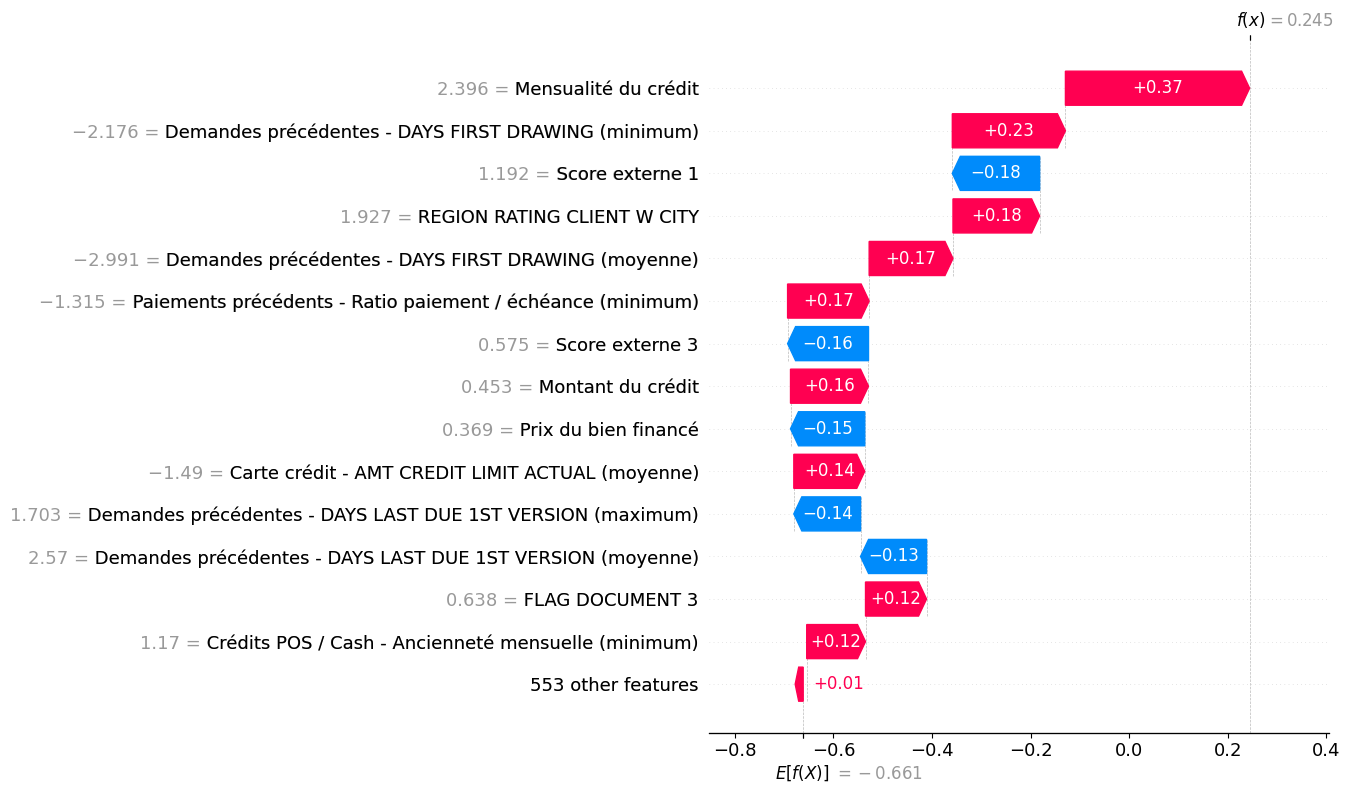

In [ ]:
shap_values.feature_names = readable_feature_names
client_idx = 24
shap.plots.waterfall(
    shap_values[client_idx],
    max_display=15
)

In [ ]:


client_proba = best_model_optuna.predict_proba(
    X_shap.iloc[[client_idx]]
)[0, 1]

print("Probabilité de défaut :", round(client_proba, 4))
print("Seuil métier :", best_threshold)

decision = "Défaut prédit / crédit refusé" if client_proba >= best_threshold else "Non-défaut prédit / crédit accepté"

print(decision)

Probabilité de défaut : 0.5608
Seuil métier : 0.51
Défaut prédit / crédit refusé


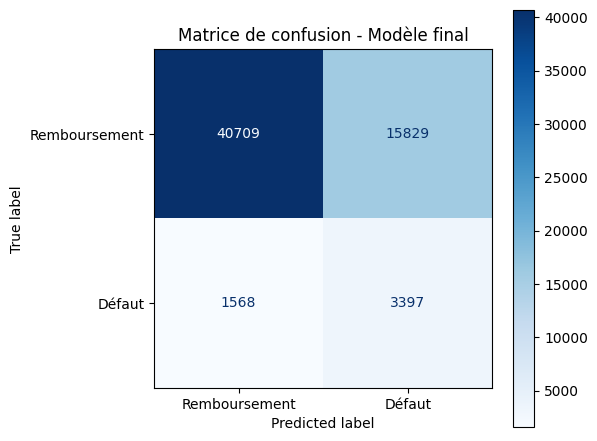

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Probabilités
y_proba = best_model_optuna.predict_proba(X_test)[:, 1]

# Application du seuil métier
y_pred = (y_proba >= best_threshold).astype(int)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Affichage
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Remboursement", "Défaut"]
)

disp.plot(ax=ax, cmap="Blues", values_format="d")

plt.title("Matrice de confusion - Modèle final")
plt.tight_layout()
plt.show()

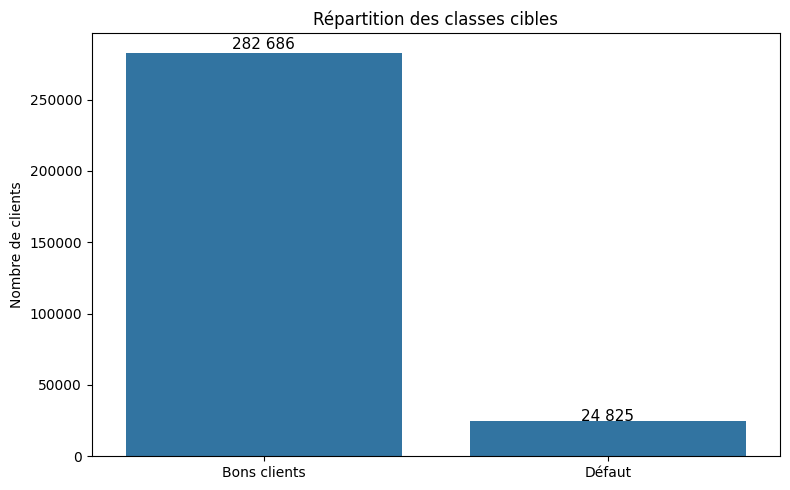

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

class_counts = df["TARGET"].value_counts().sort_index()

plot_df = pd.DataFrame({
    "Classe": ["Bons clients", "Défaut"],
    "Nombre": class_counts.values
})

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=plot_df,
    x="Classe",
    y="Nombre"
)

for i, value in enumerate(plot_df["Nombre"]):
    ax.text(
        i,
        value + (value * 0.01),
        f"{value:,}".replace(",", " "),
        ha="center",
        fontsize=11
    )

plt.title("Répartition des classes cibles")
plt.ylabel("Nombre de clients")
plt.xlabel("")
plt.tight_layout()
plt.show()

In [ ]:
import os
import json
import joblib
import pandas as pd

# ============================================================
# PARAMÈTRES
# ============================================================

EXPORT_DIR = "exports_projet8"

ARTIFACTS_DIR = os.path.join(EXPORT_DIR, "artifacts")
REFERENCE_DIR = os.path.join(EXPORT_DIR, "data", "reference")
FIXTURE_DIR = os.path.join(EXPORT_DIR, "tests", "fixtures")

os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(REFERENCE_DIR, exist_ok=True)
os.makedirs(FIXTURE_DIR, exist_ok=True)

# ============================================================
# VARIABLES A ADAPTER SI BESOIN
# ============================================================

pipeline = best_pipeline          # <- pipeline final entraîné
decision_threshold = best_threshold   # <- seuil optimisé

# dictionnaire contenant les métriques du modèle
reference_metrics = {
    "roc_auc": metrics["roc_auc"],
    "precision": metrics["precision"],
    "recall": metrics["recall"],
    "f1_score": metrics["f1_score"],
    "business_cost": metrics["business_cost"],
    "decision_threshold": decision_threshold
}

# ============================================================
# 1. Export du pipeline complet
# ============================================================

joblib.dump(
    pipeline,
    os.path.join(
        ARTIFACTS_DIR,
        "model_pipeline.joblib"
    )
)

print("✓ model_pipeline.joblib")

# ============================================================
# 2. model_config.json
# ============================================================

model_config = {
    "model_name": "home_credit_scoring_model",
    "model_version": "1.0.0",
    "decision_threshold": float(decision_threshold),
    "fn_cost": 10,
    "fp_cost": 1
}

with open(
    os.path.join(
        ARTIFACTS_DIR,
        "model_config.json"
    ),
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        model_config,
        f,
        indent=4,
        ensure_ascii=False
    )

print("✓ model_config.json")

# ============================================================
# 3. feature_schema.json
# ============================================================

feature_schema = {
    "features": [
        {
            "name": col,
            "dtype": str(X_train[col].dtype)
        }
        for col in X_train.columns
    ]
}

with open(
    os.path.join(
        ARTIFACTS_DIR,
        "feature_schema.json"
    ),
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        feature_schema,
        f,
        indent=4,
        ensure_ascii=False
    )

print("✓ feature_schema.json")

# ============================================================
# 4. reference_metrics.json
# ============================================================

with open(
    os.path.join(
        ARTIFACTS_DIR,
        "reference_metrics.json"
    ),
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        reference_metrics,
        f,
        indent=4,
        ensure_ascii=False
    )

print("✓ reference_metrics.json")

# ============================================================
# 5. reference_data.parquet
# ============================================================

reference_data = X_train.sample(
    min(len(X_train), 10000),
    random_state=42
)

reference_data.to_parquet(
    os.path.join(
        REFERENCE_DIR,
        "reference_data.parquet"
    ),
    index=False
)

print("✓ reference_data.parquet")

# ============================================================
# 6. valid_client.json
# ============================================================

valid_client = (
    X_test.iloc[0]
    .astype(object)
    .where(pd.notnull(X_test.iloc[0]), None)
)

with open(
    os.path.join(
        FIXTURE_DIR,
        "valid_client.json"
    ),
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        valid_client.to_dict(),
        f,
        indent=4,
        ensure_ascii=False
    )

print("✓ valid_client.json")

# ============================================================
# 7. expected_prediction.json
# ============================================================

probability = float(
    pipeline.predict_proba(
        X_test.iloc[[0]]
    )[0, 1]
)

prediction = int(
    probability >= decision_threshold
)

expected_prediction = {
    "default_probability": probability,
    "prediction": prediction
}

with open(
    os.path.join(
        FIXTURE_DIR,
        "expected_prediction.json"
    ),
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        expected_prediction,
        f,
        indent=4,
        ensure_ascii=False
    )

print("✓ expected_prediction.json")

print("\n===============================")
print("Export terminé.")
print("Les fichiers sont dans :")
print(EXPORT_DIR)
print("===============================")